In [ ]:
# Instalasi Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data dan Pengecekan data
DATA_PATH = "diabetes_frankurt_germany.csv"
data = pd.read_csv(DATA_PATH)
duplicate_count = data.duplicated().sum()
missing_per_column = data.isnull().sum()
zero_counts = (data.drop(columns=["Outcome"]) == 0).sum()

In [ ]:
# Imputasi dengan KNNImputer
cols_impute = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data_impute = data.copy()
data_impute[cols_impute] = data_impute[cols_impute].replace(0, np.nan)
X_for_impute = data_impute.drop(columns=["Outcome"])
y = data_impute["Outcome"]
imputer_knn = KNNImputer(n_neighbors=5)
X_imputed = imputer_knn.fit_transform(X_for_impute)
data = pd.DataFrame(X_imputed, columns=X_for_impute.columns)
data["Outcome"] = y.to_numpy()

In [ ]:
# Split data
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# normalisasi dengan MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [ ]:
# balancing dengan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 1483
Jumlah data validation: 371

Train index: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 64, 66, 68, 72, 74, 75, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 186, 187, 189, 190, 191, 193, 195, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 213, 214, 215, 216, 217, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 232, 234, 235, 236, 238, 241, 242, 243, 244, 245, 246, 248, 2

In [ ]:
# membuat model KNN dengan GridSearchCV
param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
knn_final = grid_knn.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Best Score: 0.9445
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.9461
Fold 2: 0.9380
Fold 3: 0.9326
Fold 4: 0.9434
Fold 5: 0.9622
Mean: 0.9445


In [ ]:
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)

print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")

results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")

lr_final = grid_lr.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7481
LR Best Params: {'C': np.float64(0.012742749857031334), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7601
Fold 2: 0.7089
Fold 3: 0.7466
Fold 4: 0.7655
Fold 5: 0.7595
Mean: 0.7481


In [ ]:
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)

print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")

results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")

svm_final = grid_svm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.9180
SVM Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9326
Fold 2: 0.9218
Fold 3: 0.9057
Fold 4: 0.9030
Fold 5: 0.9270
Mean: 0.9180


In [ ]:
# membuat model MLP dengan GridSearchCV
param_grid_mlp = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}

grid_mlp = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_mlp,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_mlp.fit(X_train_smote, y_train_smote)

print(f"MLP Best Score: {grid_mlp.best_score_:.4f}")
print(f"MLP Best Params: {grid_mlp.best_params_}")

results_mlp = pd.DataFrame(grid_mlp.cv_results_)
best_idx = grid_mlp.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_mlp.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_mlp.best_score_:.4f}")

mlp_final = grid_mlp.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
MLP Best Score: 0.8290
MLP Best Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'max_iter': 1000}
Fold 1: 0.8113
Fold 2: 0.8329
Fold 3: 0.8329
Fold 4: 0.8194
Fold 5: 0.8486
Mean: 0.8290


In [43]:
# membuat fitur training meta learner dengan prediksi probabilitas
prediksi_lr = cross_val_predict(lr_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_knn = cross_val_predict(knn_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_svm = cross_val_predict(svm_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_mlp = cross_val_predict(mlp_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
fitur_meta = np.column_stack([prediksi_lr, prediksi_knn, prediksi_svm, prediksi_mlp])
df_fitur_meta = pd.DataFrame(
    fitur_meta,
    columns=[
        "lr_prob_0", "lr_prob_1",
        "knn_prob_0", "knn_prob_1",
        "svm_prob_0", "svm_prob_1",
        "mlp_prob_0", "mlp_prob_1",
    ],
)

In [ ]:
# membuat fitur testing meta learner dengan prediksi probabilitas
prediksi_uji_lr = lr_final.predict_proba(X_test_scaled)
prediksi_uji_knn = knn_final.predict_proba(X_test_scaled)
prediksi_uji_svm = svm_final.predict_proba(X_test_scaled)
prediksi_uji_mlp = mlp_final.predict_proba(X_test_scaled)
fitur_meta_uji = np.column_stack([prediksi_uji_lr, prediksi_uji_knn, prediksi_uji_svm, prediksi_uji_mlp])
df_fitur_meta_uji = pd.DataFrame(
    fitur_meta_uji,
    columns=df_fitur_meta.columns,
)

Test Meta-features shape: (600, 8)
   lr_prob_0  lr_prob_1  knn_prob_0  knn_prob_1    svm_prob_0  svm_prob_1  \
0   0.442662   0.557338         0.0         1.0  1.928176e-01    0.807182   
1   0.559363   0.440637         1.0         0.0  9.919510e-01    0.008049   
2   0.400757   0.599243         0.0         1.0  9.600449e-02    0.903996   
3   0.478778   0.521222         0.0         1.0  1.929699e-01    0.807030   
4   0.458693   0.541307         0.0         1.0  9.151205e-14    1.000000   

   mlp_prob_0  mlp_prob_1  
0    0.568190    0.431810  
1    0.999434    0.000566  
2    0.230677    0.769323  
3    0.315904    0.684096  
4    0.012237    0.987763  


In [46]:
X_meta_latih = df_fitur_meta
y_meta_latih = y_train_smote

X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_test

In [ ]:
# membuat model KNN Meta dengan GridSearchCV
grid_knn_meta = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_meta_latih, y_meta_latih)

print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")

results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")

knn_meta_final = grid_knn_meta.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Meta Best Score: 0.9455
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Fold 1: 0.9542
Fold 2: 0.9488
Fold 3: 0.9326
Fold 4: 0.9326
Fold 5: 0.9595
Mean: 0.9455


In [48]:
# membuat model Logistic Regression Meta dengan GridSearchCV
grid_logreg_meta = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_meta_latih, y_meta_latih)

print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")

results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")

logreg_meta_final = grid_logreg_meta.best_estimator_


Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.9439
LogReg Meta Best Params: {'C': np.float64(0.615848211066026), 'penalty': 'l1', 'solver': 'liblinear'}
Fold 1: 0.9542
Fold 2: 0.9380
Fold 3: 0.9380
Fold 4: 0.9326
Fold 5: 0.9568
Mean: 0.9439


In [49]:
# membuat model Support Vector Machine Meta dengan GridSearchCV
grid_svm_meta = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_meta_latih, y_meta_latih)

print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")

results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")

svm_meta_final = grid_svm_meta.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.9450
SVM Meta Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'linear'}
Fold 1: 0.9515
Fold 2: 0.9434
Fold 3: 0.9353
Fold 4: 0.9380
Fold 5: 0.9568
Mean: 0.9450


In [50]:
# membuat model ANN Meta dengan GridSearchCV
grid_mlp_meta = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_mlp,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_mlp_meta.fit(X_meta_latih, y_meta_latih)

print(f"MLP Meta Best Score: {grid_mlp_meta.best_score_:.4f}")
print(f"MLP Meta Best Params: {grid_mlp_meta.best_params_}")

results_mlp_meta = pd.DataFrame(grid_mlp_meta.cv_results_)
best_idx = grid_mlp_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_mlp_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_mlp_meta.best_score_:.4f}")

mlp_meta_final = grid_mlp_meta.best_estimator_


Fitting 5 folds for each of 144 candidates, totalling 720 fits
MLP Meta Best Score: 0.9472
MLP Meta Best Params: {'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': (20, 10), 'max_iter': 500}
Fold 1: 0.9596
Fold 2: 0.9434
Fold 3: 0.9407
Fold 4: 0.9272
Fold 5: 0.9649
Mean: 0.9472


In [ ]:
# contoh prediksi dengan model ANN Meta terbaik
best_meta_ann = grid_mlp_meta.best_estimator_
best_meta_ann.predict(X_meta_uji)

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,

In [54]:
# pengujian model meta learner terbaik dengan data uji
pred_model_dasar = {
    "LogReg": lr_final.predict(X_test_scaled),
    "KNN": knn_final.predict(X_test_scaled),
    "SVM": svm_final.predict(X_test_scaled),
    "MLP": mlp_final.predict(X_test_scaled),
}

stacking_predictions = {
    "Stacking_KNN": knn_meta_final.predict(X_meta_uji),
    "Stacking_SVM": svm_meta_final.predict(X_meta_uji),
    "Stacking_MLP": mlp_meta_final.predict(X_meta_uji),
    "Stacking_LogReg": logreg_meta_final.predict(X_meta_uji),
}


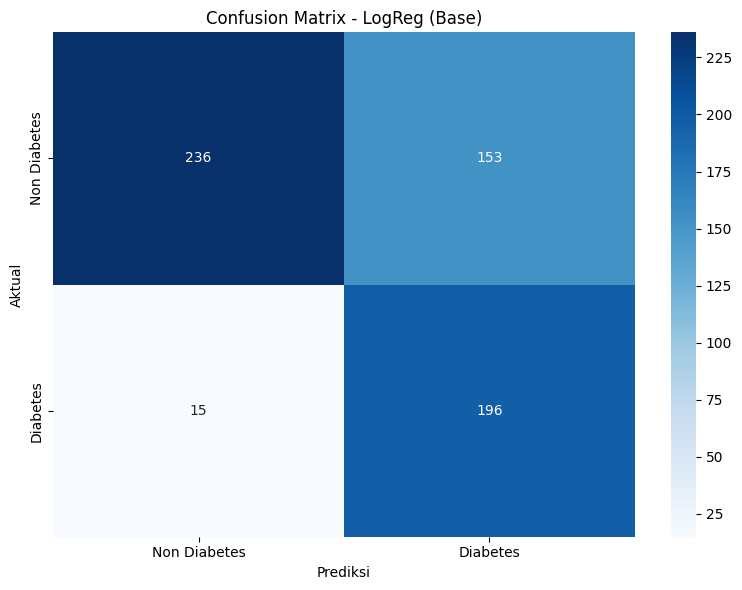

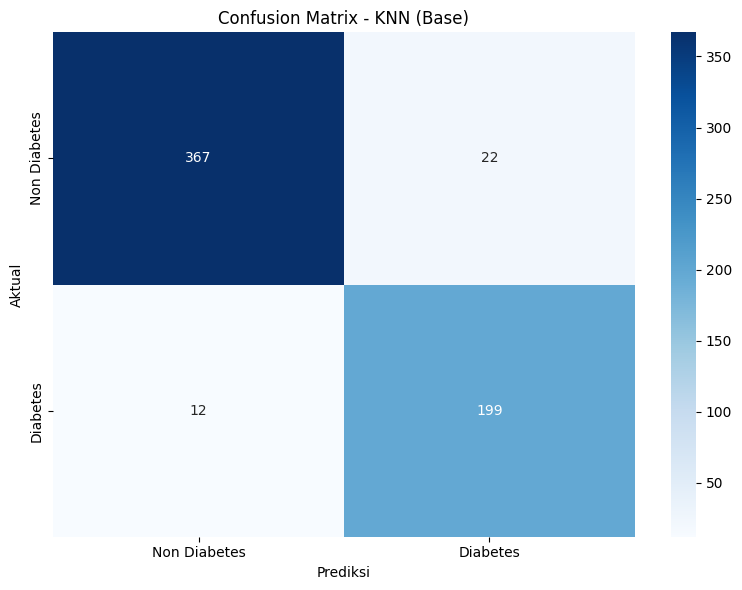

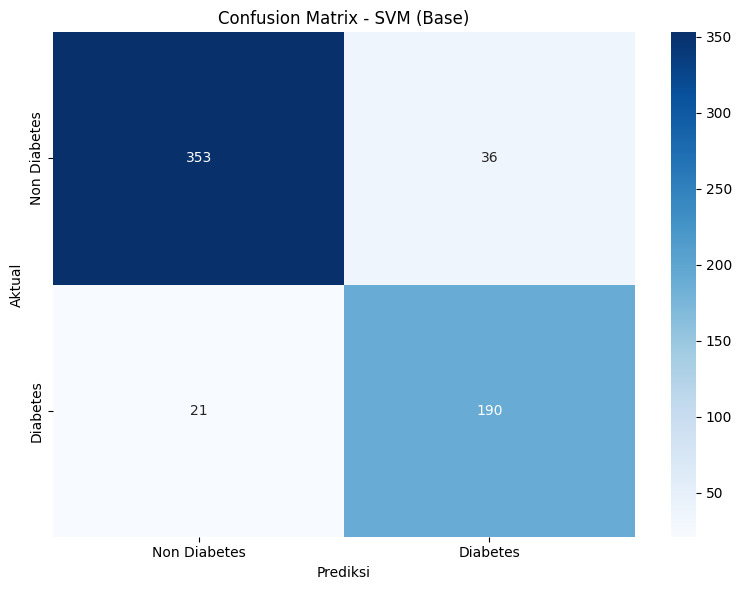

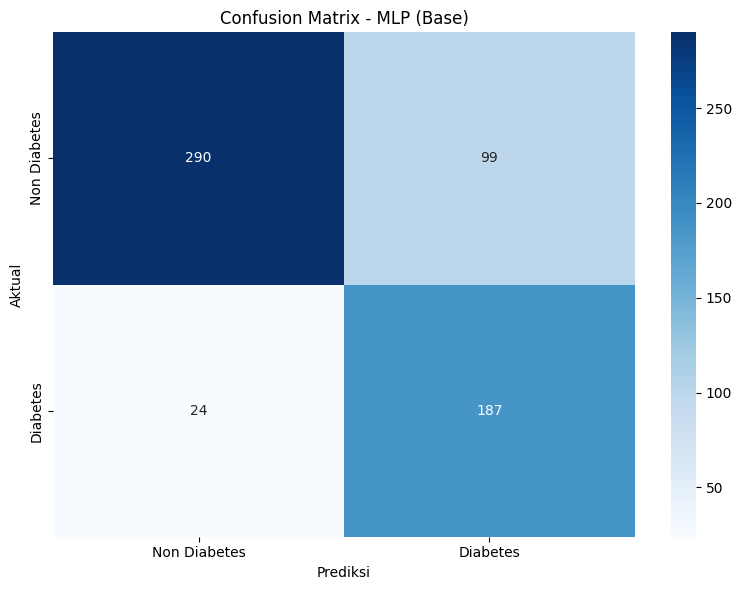

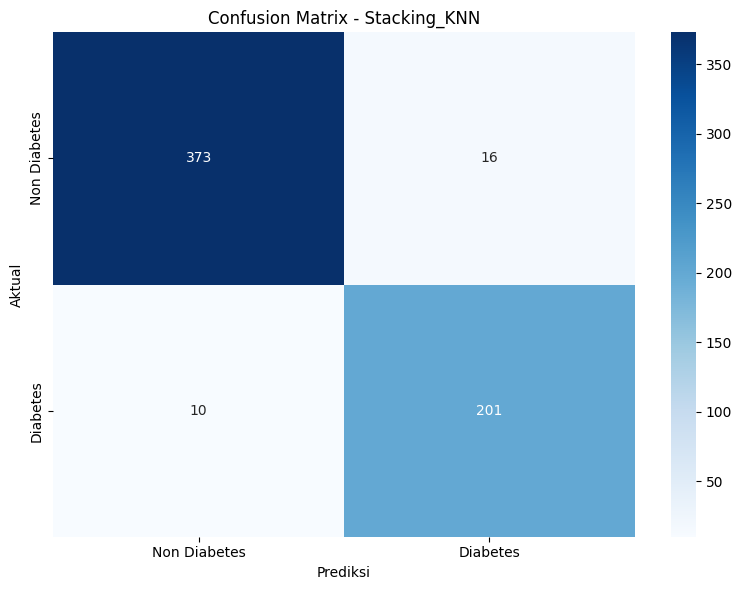

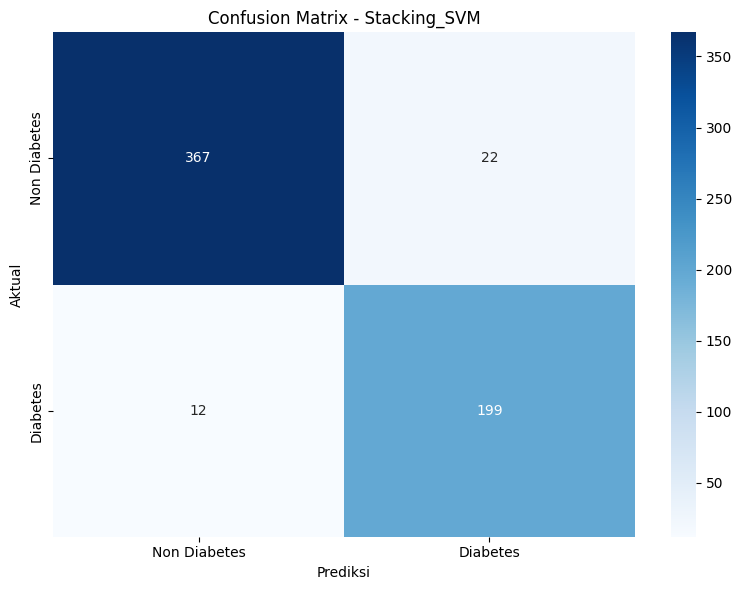

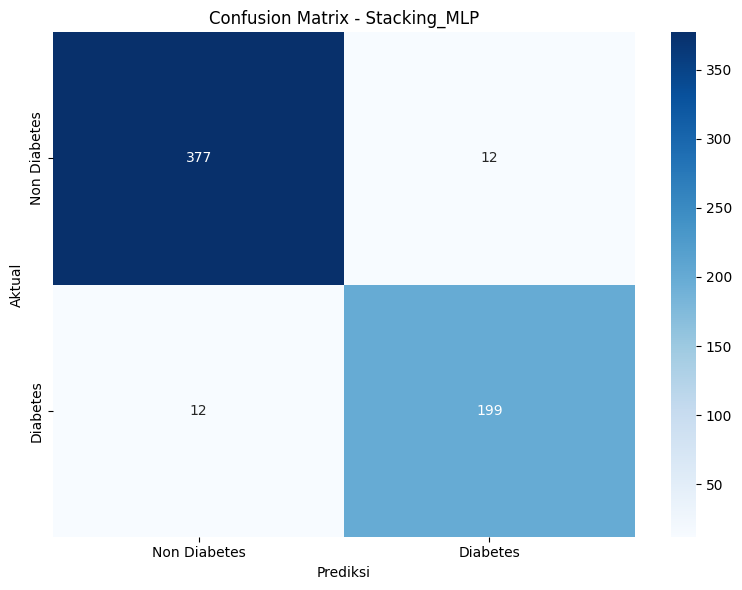

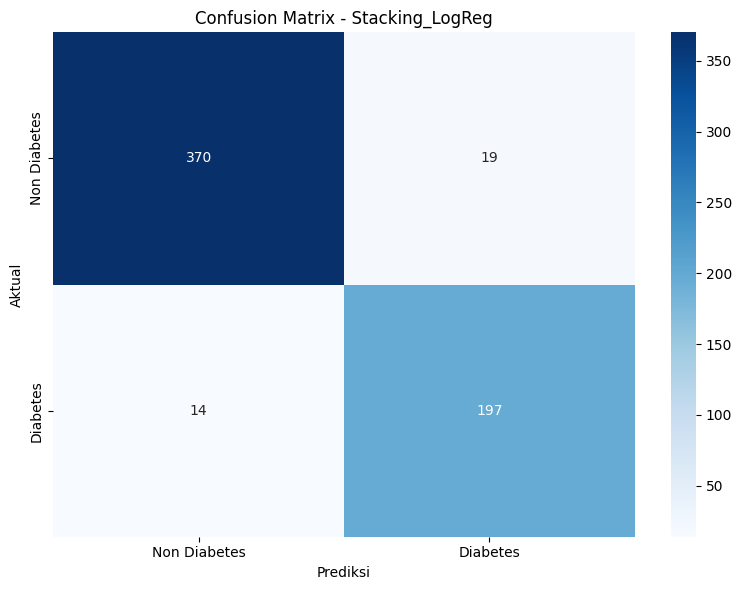

In [55]:
# evaluasi model
# ================================
# 4.2.14 Confusion Matrix
# ================================
def plot_confusion_matrix(y_asli, y_prediksi, nama_model):
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_asli, y_prediksi)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Non Diabetes", "Diabetes"],
        yticklabels=["Non Diabetes", "Diabetes"],
    )
    ax.set_title(f"Confusion Matrix - {nama_model}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

for nama_model, prediksi in pred_model_dasar.items():
    plot_confusion_matrix(y_test, prediksi, f"{nama_model} (Base)")

for nama_model, prediksi in stacking_predictions.items():
    plot_confusion_matrix(y_test, prediksi, nama_model)

In [57]:
def hitung_metrik(y_asli, y_prediksi, nama_model):
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi)
    recall = recall_score(y_asli, y_prediksi)
    f1 = f1_score(y_asli, y_prediksi)
    return {"Model": nama_model, "Akurasi": akurasi, "Presisi": presisi, "Recall": recall, "Skor-F1": f1}

hasil_perbandingan = []
for nama_model, prediksi in pred_model_dasar.items():
    hasil_perbandingan.append(hitung_metrik(y_test, prediksi, nama_model))
for nama_model, prediksi in stacking_predictions.items():
    hasil_perbandingan.append(hitung_metrik(y_test, prediksi, nama_model))

df_perbandingan = pd.DataFrame(hasil_perbandingan)
print(df_perbandingan)

             Model   Akurasi   Presisi    Recall   Skor-F1
0           LogReg  0.720000  0.561605  0.928910  0.700000
1              KNN  0.943333  0.900452  0.943128  0.921296
2              SVM  0.905000  0.840708  0.900474  0.869565
3              MLP  0.795000  0.653846  0.886256  0.752515
4     Stacking_KNN  0.956667  0.926267  0.952607  0.939252
5     Stacking_SVM  0.943333  0.900452  0.943128  0.921296
6     Stacking_MLP  0.960000  0.943128  0.943128  0.943128
7  Stacking_LogReg  0.945000  0.912037  0.933649  0.922717
